In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import pandas as pd
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import to_hex
from shapely.geometry import Polygon
from matplotlib.path import Path
import pandas as pd
import matplotlib.gridspec as gridspec
import glob
import time

In [ ]:
# ==========================================
# ADAPTATION DONNÉES GADI + MSLP EN CERCLES
# ==========================================

import glob, os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as cticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import seaborn as sns

# ── 1. CHARGEMENT PR DEPUIS GADI ─────────────────────────────────────────────
import dask
dask.config.set(scheduler='synchronous')

def preprocess_pr_global(ds):
    """Garde la grille globale pour le plot de carte (pas de découpe)."""
    ds = ds.sortby('latitude')
    if 'expver' in ds.dims:
        ds = ds.sel(expver=1, drop=True).combine_first(ds.sel(expver=5, drop=True))
    return ds[['tp']]

files_pr = sorted(glob.glob(
    '/g/data/rt52/era5/single-levels/monthly-averaged/tp/**/*.nc', recursive=True))
years_needed = [str(y) for y in range(1940, 2024)]
files_pr = [f for f in files_pr if any(yr in f for yr in years_needed)]

ds_pr = xr.open_mfdataset(
    files_pr, parallel=False, preprocess=preprocess_pr_global,
    combine='by_coords', engine='netcdf4', chunks={'time': 12}
)
prec = (ds_pr.tp * 1000).rename({'latitude': 'lat', 'longitude': 'lon'})
print(f"PR chargée ✓ — {len(files_pr)} fichiers")

# ── 2. CHARGEMENT MSLP DEPUIS GADI (pour les cercles) ────────────────────────
def preprocess_mslp_global(ds):
    ds = ds.sortby('latitude')
    if 'expver' in ds.dims:
        ds = ds.sel(expver=1, drop=True).combine_first(ds.sel(expver=5, drop=True))
    return ds[['msl']]

files_mslp = sorted(glob.glob(
    '/g/data/rt52/era5/single-levels/monthly-averaged/msl/**/*.nc', recursive=True))
files_mslp = [f for f in files_mslp if any(yr in f for yr in years_needed)]

ds_mslp = xr.open_mfdataset(
    files_mslp, parallel=False, preprocess=preprocess_mslp_global,
    combine='by_coords', engine='netcdf4', chunks={'time': 12}
)
mslp = (ds_mslp.msl / 100.0).rename({'latitude': 'lat', 'longitude': 'lon'})  # Pa → hPa
print(f"MSLP chargée ✓ — {len(files_mslp)} fichiers")

In [3]:
# ── 3. CLIMATOLOGIES ─────────────────────────────────────────────────────────
mon_clim_pr   = prec.groupby('time.month').mean(dim='time').compute(scheduler='synchronous')
mon_clim_mslp = mslp.groupby('time.month').mean(dim='time').compute(scheduler='synchronous')
print("Climatologies calculées ✓")

# ── 4. CONFIGURATION ANNÉES ──────────────────────────────────────────────────
y1_prev = [1954, 1970, 1973, 1983, 1998, 2007, 2010, 2016, 2020]
y1_curr = [1955, 1971, 1974, 1984, 1999, 2008, 2011, 2017, 2021]
months_keys = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
climatologies = {
    "ER": {months_keys[m-1]: mon_clim_pr.sel(month=m) for m in range(1, 13)}
}
clim_mslp_dict = {months_keys[m-1]: mon_clim_mslp.sel(month=m) for m in range(1, 13)}

# ── 5. CALCUL ANOMALIES PR + MSLP PAR SAISON/ANNÉE ───────────────────────────
er_results = {'SON': {}, 'DJF': {}}

for y_lab in ["yr1", "yr2", "yr3"]:
    offset = 0 if y_lab == "yr1" else (1 if y_lab == "yr2" else 2)
    p_years = [y + offset for y in y1_prev]
    c_years = [y + offset for y in y1_curr]
    if y_lab == "yr3":
        idx3 = [2, 4, 8]
        p_years = [p_years[i] for i in idx3]
        c_years = [c_years[i] for i in idx3]

    for s_name in ['SON', 'DJF']:
        event_pr, event_mslp = [], []

        for py, cy in zip(p_years, c_years):
            if s_name == 'SON':
                blk_pr   = prec.sel(time=(prec['time.year']==py)   & prec['time.month'].isin([9,10,11]))
                blk_mslp = mslp.sel(time=(mslp['time.year']==py)   & mslp['time.month'].isin([9,10,11]))
            else:
                blk_pr   = xr.concat([
                    prec.sel(time=(prec['time.year']==py)  & (prec['time.month']==12)),
                    prec.sel(time=(prec['time.year']==cy)  & prec['time.month'].isin([1,2]))
                ], dim='time')
                blk_mslp = xr.concat([
                    mslp.sel(time=(mslp['time.year']==py)  & (mslp['time.month']==12)),
                    mslp.sel(time=(mslp['time.year']==cy)  & mslp['time.month'].isin([1,2]))
                ], dim='time')
            event_pr.append(blk_pr.mean(dim='time'))
            event_mslp.append(blk_mslp.mean(dim='time'))

        all_pr   = xr.concat(event_pr,   dim='event').compute(scheduler='synchronous')
        all_mslp = xr.concat(event_mslp, dim='event').compute(scheduler='synchronous')

        # Climatologie saisonnière PR
        if s_name == 'SON':
            clim_pr   = (climatologies["ER"]['sep'] + climatologies["ER"]['oct'] + climatologies["ER"]['nov']) / 3
            clim_mslp = (clim_mslp_dict['sep'] + clim_mslp_dict['oct'] + clim_mslp_dict['nov']) / 3
        else:
            clim_pr   = (climatologies["ER"]['dec'] + climatologies["ER"]['jan'] + climatologies["ER"]['feb']) / 3
            clim_mslp = (clim_mslp_dict['dec'] + clim_mslp_dict['jan'] + clim_mslp_dict['feb']) / 3

        anom_pr   = (all_pr.mean(dim='event') / clim_pr - 1) * 100
        anom_mslp = all_mslp.mean(dim='event') - clim_mslp  # anomalie en hPa

        # Masque significativité PR
        diff   = all_pr - clim_pr
        thresh = np.ceil(len(p_years) * 0.85)
        sig    = ((diff > 0).sum(dim='event') >= thresh) | ((diff < 0).sum(dim='event') >= thresh)
        mask   = (sig & (np.abs(anom_pr) > 10)).astype(float)

        er_results[s_name][y_lab] = {
            'pr': anom_pr, 'mask': mask,
            'mslp': anom_mslp,          # ← NOUVEAU
            'n': len(p_years)
        }

print("Anomalies calculées ✓")


Climatologies calculées ✓
Anomalies calculées ✓


In [4]:
def add_mslp_contours(ax, mslp_anom, lon_range=(80, 180), lat_range=(-55, 10)):
    mslp_reg = mslp_anom.sel(
        lon=slice(lon_range[0], lon_range[1]),
        lat=slice(lat_range[0], lat_range[1])
    )
    lons = mslp_reg.lon.values
    lats = mslp_reg.lat.values
    data = mslp_reg.values

    # ── Positifs (vert) ───────────────────────────────────────────────────────
    cs_pos_dash = ax.contour(lons, lats, data, levels=[0.5],
                             colors='red', linewidths=0.5, linestyles='--',
                             transform=ccrs.PlateCarree(), zorder=6)
    ax.clabel(cs_pos_dash, fmt='%+.1f', fontsize=9, inline=True)  # ← .1f pour "0.5"

    cs_pos = ax.contour(lons, lats, data, levels=[1, 1.5, 2],
                        colors='red', linewidths=[0.8, 1.4, 2.0],
                        linestyles='-',
                        transform=ccrs.PlateCarree(), zorder=6)
    ax.clabel(cs_pos, fmt='%+.1f', fontsize=9, inline=True)       # ← .1f pour "1.5"

    # ── Négatifs (rouge) ──────────────────────────────────────────────────────
    cs_neg_dash = ax.contour(lons, lats, data, levels=[-0.5],
                             colors='blue', linewidths=0.5, linestyles='--',
                             transform=ccrs.PlateCarree(), zorder=6)
    ax.clabel(cs_neg_dash, fmt='%+.1f', fontsize=9, inline=True)  # ← .1f pour "-0.5"

    cs_neg = ax.contour(lons, lats, data, levels=[-2, -1.5, -1],
                        colors='blue', linewidths=[2.0, 1.4, 0.8],
                        linestyles='-',
                        transform=ccrs.PlateCarree(), zorder=6)
    ax.clabel(cs_neg, fmt='%+.1f', fontsize=9, inline=True)       # ← .1f pour "-1.5"

/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/jobfs/164916878.gadi-pbs/ipykernel_2656422/2681975803.py:97: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')


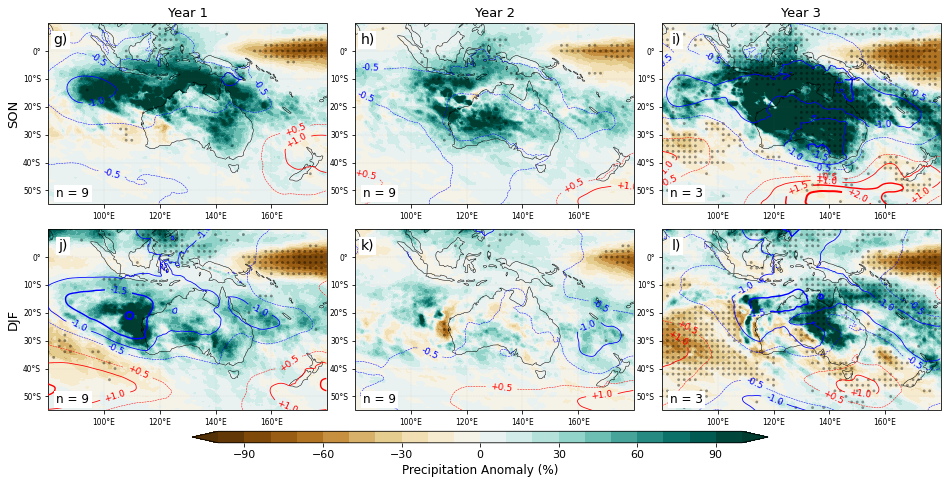

In [5]:
import cartopy.mpl.ticker as cticker
# ── 7. PLOT ───────────────────────────────────────────────────────────────────
color_ex  = sns.color_palette("BrBG", n_colors=22)
BG        = color_ex[11:22]
color10   = sns.color_palette("BrBG", n_colors=8)
Br        = color10[0:4]
Br.extend(BG)
cmap_son  = ListedColormap(Br)

lvl_djf = np.arange(-100, 110, 10)

fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.1, hspace=-0.1)

im_son, im_djf = None, None
labels = ['g)','h)','i)','j)','k)','l)']
label_idx = 0

for r, seas in enumerate(['SON', 'DJF']):
    c_map = 'BrBG' if seas == 'SON' else 'BrBG'
    lvls  = lvl_djf  if seas == 'SON' else lvl_djf

    for c, y_lab in enumerate(["yr1", "yr2", "yr3"]):
        ax = axes[r, c]
        if y_lab not in er_results[seas]: continue

        data_dict = er_results[seas][y_lab]
        pr        = data_dict['pr']
        mask      = data_dict['mask']
        mslp_anom = data_dict['mslp']   # ← NOUVEAU

        ln = [co for co in pr.coords if 'lon' in co][0]
        lt = [co for co in pr.coords if 'lat' in co][0]

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.set_extent([80, 180, -55, 10], crs=ccrs.PlateCarree())

        # Précipitations
        im = ax.contourf(pr[ln], pr[lt], pr.values,
                         levels=lvls, cmap=c_map, extend='both',
                         transform=ccrs.PlateCarree())
        if c == 0:
            if seas == 'SON': im_son = im
            else:             im_djf = im

        # Stippling
        # Optionnel : Sous-échantillonnage pour éviter la saturation si la grille est fine
        skip = 8  # Augmenter si les points sont trop serrés
        m_plot = mask.isel({lt: slice(None, None, skip), ln: slice(None, None, skip)})
        
        # Trouver les indices lat/lon où le masque est vrai
        # On utilise np.where sur les valeurs du masque
        lons_mesh, lats_mesh = np.meshgrid(m_plot[ln], m_plot[lt])
        points_x = lons_mesh[m_plot.values > 0]
        points_y = lats_mesh[m_plot.values > 0]

        if len(points_x) > 0:
            ax.scatter(points_x, points_y, 
                       s=8,             # TAILLE DES POINTS (ajustez entre 5 et 20)
                       color='black', 
                       marker='o',       # 'o' pour des ronds, '.' pour des points plus fins
                       alpha=0.4,        # Opacité pour ne pas masquer totalement la couleur
                       edgecolors='none', 
                       transform=ccrs.PlateCarree(),
                       zorder=5)         # S'assure que c'est au-dessus de contourf

        # ── CERCLES MSLP ─────────────────────────────────────────────────────
        add_mslp_contours(ax, mslp_anom, lon_range=(80, 180), lat_range=(-55, 10))

        # Labels
        ax.text(0.03, 0.04, f'n = {data_dict["n"]}',
                transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
        ax.text(0.07, 0.87, labels[label_idx],
                transform=ax.transAxes, fontsize=14, va='bottom', ha='right',
                bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
        label_idx += 1

        ax.set_title("")
        if r == 0: ax.set_title(f"Year {c+1}", fontsize=13)
        if c == 0:
            ax.text(-0.1, 0.5, seas, transform=ax.transAxes,
                    fontsize=13, rotation=90, va='center', ha='right')

        ax.set_xticks([100, 120, 140, 160], crs=ccrs.PlateCarree())
        ax.set_yticks([-50, -40, -30, -20, -10, 0], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
        ax.tick_params(labelsize=7.5)
        ax.grid(linewidth=0.3, linestyle='--', color='gray', alpha=0.3)

# Colorbars
# --- 4. COLORBAR UNIQUE EN BAS ---
# Position : [gauche, bas, largeur, hauteur]
cbar_ax = fig.add_axes([0.25, 0.11, 0.5, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Precipitation Anomaly (%)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

#fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/Pr_ERA5_TLN_85pct_MSLP.png',
#            bbox_inches='tight', dpi=600)
plt.show()

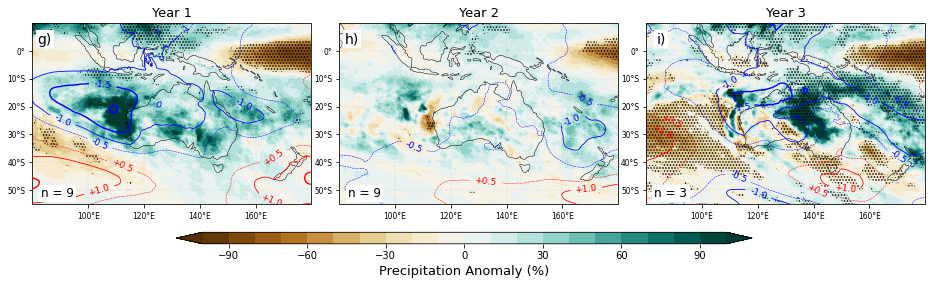

In [6]:
import cartopy.mpl.ticker as cticker
# ── 7. PLOT ───────────────────────────────────────────────────────────────────
color_ex  = sns.color_palette("BrBG", n_colors=22)
BG        = color_ex[11:22]
color10   = sns.color_palette("BrBG", n_colors=8)
Br        = color10[0:4]
Br.extend(BG)
cmap_son  = ListedColormap(Br)

lvl_son = np.arange(-100, 275, 25)
lvl_djf = np.arange(-100, 110, 10)


fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.1)

im_djf = None
labels = ['g)', 'h)', 'i)']
label_idx = 0

for c, y_lab in enumerate(["yr1", "yr2", "yr3"]):
    ax = axes[c]
    if y_lab not in er_results['DJF']: continue

    data_dict = er_results['DJF'][y_lab]
    pr        = data_dict['pr']
    mask      = data_dict['mask']
    mslp_anom = data_dict['mslp']

    ln = [co for co in pr.coords if 'lon' in co][0]
    lt = [co for co in pr.coords if 'lat' in co][0]

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([80, 180, -55, 10], crs=ccrs.PlateCarree())

    im = ax.contourf(pr[ln], pr[lt], pr.values,
                     levels=lvl_djf, cmap='BrBG', extend='both',
                     transform=ccrs.PlateCarree())
    if c == 0: im_djf = im

    ax.contourf(mask[ln], mask[lt], mask.where(mask > 0),
                levels=[0.5, 1.5], colors='none', hatches=['....'],
                transform=ccrs.PlateCarree())

    add_mslp_contours(ax, mslp_anom, lon_range=(80, 180), lat_range=(-55, 10))

    ax.text(0.03, 0.04, f'n = {data_dict["n"]}',
            transform=ax.transAxes, fontsize=12,
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
    ax.text(0.07, 0.87, labels[label_idx],
            transform=ax.transAxes, fontsize=14, va='bottom', ha='right',
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
    label_idx += 1

    ax.set_title(f"Year {c+1}", fontsize=13)

    ax.set_xticks([100, 120, 140, 160], crs=ccrs.PlateCarree())
    ax.set_yticks([-50, -40, -30, -20, -10, 0], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
    ax.tick_params(labelsize=7.5)
    ax.grid(linewidth=0.3, linestyle='--', color='gray', alpha=0.3)

# --- 3. COLORBAR HORIZONTALE EN DESSOUS ---
if im_djf is not None:
    # [left, bottom, width, height] en coordonnées relatives à la figure
    cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.04])
    cbar = fig.colorbar(im_djf, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Precipitation Anomaly (%)', fontsize=13)
    cbar.ax.tick_params(labelsize=10)

#fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/Pr_ERA5_TLN_85pct_DJF_MSLP.png',
#            bbox_inches='tight', dpi=600)
plt.show()

## Adding the Scatter Plot

In [1]:
import xarray as xr
import glob
import numpy as np
import dask
import gc
import os

# Optimisation Dask pour NCI
dask.config.set(scheduler='synchronous')

years_needed = [str(y) for y in range(1940, 2025)]

def preprocess_era5(ds):
    ds = ds.sortby('latitude')
    # DÉCOUPE SPATIALE ICI (AVANT TOUT LE RESTE)
    ds = ds.sel(latitude=slice(-45, -10), longitude=slice(90, 155)) 
    
    if 'expver' in ds.dims:
        ds = ds.sel(expver=1, drop=True).combine_first(ds.sel(expver=5, drop=True))
    return ds

# ── 1. PRÉCIPITATIONS (TP) ──────────────────────────────────────────────────
files_pr = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/tp/**/*.nc', recursive=True))
files_pr = [f for f in files_pr if any(yr in f for yr in years_needed)]

ds_pr = xr.open_mfdataset(files_pr, preprocess=preprocess_era5, chunks={'time': 12})
prec_global = ds_pr.tp * 1000
prec_global = prec_global.rename({'latitude': 'lat', 'longitude': 'lon'})
print(f"PR chargée ✓ ({len(files_pr)} fichiers)")

# ── 2. ÉVAPORATION ET VENT (CORRIGÉ) ────────────────────────────────────

# Chemins exacts sur rt52 (Projet ERA5 sur NCI)
# Note : Les dossiers de variables utilisent souvent des noms courts (e, 10u, 10v)
files_e = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/e/**/*.nc', recursive=True))
files_u = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/10u/**/*.nc', recursive=True))
files_v = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/10v/**/*.nc', recursive=True))

# Filtrage par années pour éviter de charger trop de données
files_e = [f for f in files_e if any(yr in f for yr in years_needed)]
files_u = [f for f in files_u if any(yr in f for yr in years_needed)]
files_v = [f for f in files_v if any(yr in f for yr in years_needed)]

# Vérification de sécurité
if not files_u or not files_v:
    print("Attention : Fichiers vent non trouvés. Vérification des noms alternatifs...")
    # Tentative avec u10/v10 si 10u/10v échouent
    files_u = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/u10/**/*.nc', recursive=True))
    files_v = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/v10/**/*.nc', recursive=True))
    files_u = [f for f in files_u if any(yr in f for yr in years_needed)]
    files_v = [f for f in files_v if any(yr in f for yr in years_needed)]

# Chargement de l'évaporation
if files_e:
    ds_e = xr.open_mfdataset(files_e, preprocess=preprocess_era5, chunks={'time': 12})
    ev_global = ds_e.e * (-1000) 
    ev_global = ev_global.rename({'latitude': 'lat', 'longitude': 'lon'})
    print(f"Evap chargée ✓ ({len(files_e)} fichiers)")

# Chargement du vent (on combine U et V)
if files_u and files_v:
    # On ouvre U et V séparément puis on les fusionne
    ds_u = xr.open_mfdataset(files_u, preprocess=preprocess_era5, chunks={'time': 12})
    ds_v = xr.open_mfdataset(files_v, preprocess=preprocess_era5, chunks={'time': 12})
    
    # Calcul de la vitesse du vent (Wind Speed)
    # Les variables dans les fichiers sont 'u10' et 'v10' même si le dossier est '10u'
    ws_global = (ds_u.u10**2 + ds_v.v10**2)**0.5
    ws_global = ws_global.rename({'latitude': 'lat', 'longitude': 'lon'})
    print(f"Vent chargé ✓ ({len(files_u) + len(files_v)} fichiers)")
else:
    raise OSError("Impossible de trouver les fichiers de vent sur /g/data/rt52/")

# --- 1. Chemins des fichiers AWRA-L v7 ---
# --- 1. REDÉFINITION DES CONSTANTES (Indispensable) ---
LON_SLICE = slice(90, 170)        # Ajustez selon votre zone d'étude
LAT_SLICE_AUM = slice(-44, -10)   # Zone Australie pour AWRA-L

root_awra = '/g/data/iu04/australian-water-outlook/historical/v1/AWRALv7/'

sm_yearly_list = []

print("Début du chargement itératif de la Soil Moisture (0-6m)...")

for yr in years_needed:
    # 1. Construction des chemins (Vérifiez bien ces chemins sur votre session NCI)
    f0 = f"{root_awra}s0_{yr}.nc"
    fs = f"{root_awra}ss_{yr}.nc"
    fd = f"{root_awra}sd_{yr}.nc"
    
    try:
        # Ouverture individuelle
        # On utilise .drop_vars si certaines variables de métadonnées entrent en conflit
        d0 = xr.open_dataset(f0).s0.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
        ds = xr.open_dataset(fs).ss.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
        dd = xr.open_dataset(fd).sd.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
        
        # Calcul de la somme
        sm_total = d0*0.1 + ds*0.9 + dd*5
        
        # Réduction immédiate en mensuel pour gagner de la place (AWRA est souvent journalier)
        # On force le compute ici pour transformer l'objet dask en numpy léger
        sm_monthly = sm_total.resample(time='1MS').mean().compute()
        
        # Ajout à la liste
        sm_yearly_list.append(sm_monthly)
        
        # Fermeture explicite des fichiers
        d0.close(); ds.close(); dd.close()
        
    except Exception as e:
        print(f"  ⚠️ Erreur pour l'année {yr}: {e}")
        continue

    if int(yr) % 10 == 0:
        print(f"  ✓ Année {yr} traitée et ajoutée.")
        gc.collect()

# --- 3. Assemblage avec vérification ---
if len(sm_yearly_list) > 0:
    print(f"Assemblage de {len(sm_yearly_list)} années en cours...")
    sm_aum_only = xr.concat(sm_yearly_list, dim='time')
    
    # Nettoyage
    del sm_yearly_list
    gc.collect()
    print(f"✅ Soil Moisture 0-6m chargée. Taille : {sm_aum_only.nbytes / 1e6:.2f} MB")
else:
    print("❌ Erreur : La liste sm_yearly_list est vide. Vérifiez les chemins des fichiers.")

print(f"SM 0-1m loaded ✓")
print(f"SM 0-6m Deep Layer loaded ✓")

PR chargée ✓ (792 fichiers)
Evap chargée ✓ (792 fichiers)
Vent chargé ✓ (1584 fichiers)
Début du chargement itératif de la Soil Moisture (0-6m)...
  ✓ Année 1940 traitée et ajoutée.
  ✓ Année 1950 traitée et ajoutée.
  ✓ Année 1960 traitée et ajoutée.
  ✓ Année 1970 traitée et ajoutée.
  ✓ Année 1980 traitée et ajoutée.
  ✓ Année 1990 traitée et ajoutée.
  ✓ Année 2000 traitée et ajoutée.
  ✓ Année 2010 traitée et ajoutée.
  ✓ Année 2020 traitée et ajoutée.
Assemblage de 85 années en cours...
✅ Soil Moisture 0-6m chargée. Taille : 0.00 MB
SM 0-1m loaded ✓
SM 0-6m Deep Layer loaded ✓


In [2]:
# --- INITIALISATION INDISPENSABLE ---
raw_series = {}  # On crée le dictionnaire vide ici

# 1. Chargement du masque
AUMmask_path = "/g/data/m35/qr1706/TLN_AUM/AUMmask_reduit.npy"
AUMmask = np.load(AUMmask_path) 

# 2. Définition des coordonnées
lats_aum = np.linspace(-44.0, -10.25, 136) 
lons_aum = np.linspace(112.0, 153.75, 168)

# 3. Création du masque Xarray 
# Note : J'utilise 'lat' et 'lon' directement pour matcher vos données renommées
AUMmask_xr = xr.DataArray(
    AUMmask,
    coords={'lat': lats_aum, 'lon': lons_aum},
    dims=['lat', 'lon']
)

print(f"✅ Masque Xarray créé. Taille : {AUMmask_xr.shape}")

✅ Masque Xarray créé. Taille : (136, 168)


In [3]:
import psutil, os

def mem_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

# ── Diagnostic : qu'est-ce qui est dans raw_series ? ──────────────────────────
print("=== Contenu de raw_series ===")
for key, series in raw_series.items():
    is_dask = hasattr(series, 'dask')
    size_info = f"chunks={series.chunks}" if is_dask else f"shape={series.shape}"
    print(f"  {key:30s}  dask={is_dask}  {size_info}")
print(f"\nMémoire actuelle : {mem_gb():.2f} GB\n")

=== Contenu de raw_series ===

Mémoire actuelle : 0.39 GB



In [4]:
# Liste des indices (Années correspondant au début de la saison, ex: 1998 pour 1998/1999)
# Assure-toi que ces années correspondent à ton étude
nina_indices = {
    'S': [1942, 1964, 1988, 1995, 2005], # Single
    '1': [1954, 1970, 1973, 1983, 1998, 2007, 2010, 2016, 2020], # 1st year of multi-year
    '2': [1955, 1971, 1974, 1984, 1999, 2008, 2011, 2017, 2021], # 2nd year
    '3': [1975, 2000, 2022]  # 3rd year
}

print("Cellule 6 OK : Indices chargés.")

Cellule 6 OK : Indices chargés.


In [5]:
import gc
import numpy as np
import xarray as xr

# --- 1. FONCTION DE DETRENDING ---
def detrend_variable(da):
    vals = da.values.astype(float)
    dim_name = da.dims[0]
    trend = da.rolling({dim_name: 20}, center=True).mean().values.astype(float)
    trend[:10]  = np.nanmean(vals[:20])
    trend[-10:] = np.nanmean(vals[-20:])
    detrended = vals - trend
    return xr.DataArray(detrended, coords=da.coords, dims=da.dims)

# --- 2. CONFIGURATION DES SAISONS (Incluant NDJFM) ---
seasons_config = {
    'JJA':   {'months': [6, 7, 8], 'shift': False},
    'SON':   {'months': [9, 10, 11], 'shift': False},
    'DJF':   {'months': [12, 1, 2], 'shift': True},
    'NDJFM': {'months': [11, 12, 1, 2, 3], 'shift': True} # Ta saison intégrée ici !
}

all_seasonal_results = {}

datasets = {
    'prec': prec_global, 
    'ev': ev_global, 
    'ws': ws_global, 
    'sm': sm_aum_only
}


In [6]:
sm_yearly_list = []
print("Début du chargement corrigé de la SM...")

# On définit les bornes de l'Australie
LAT_AUM = slice(-10, -44)  # INVERSÉ : du Nord vers le Sud pour AWRA-L
LON_AUM = slice(112, 154)

for yr in years_needed:
    f0 = f"{root_awra}s0_{yr}.nc"
    fs = f"{root_awra}ss_{yr}.nc"
    fd = f"{root_awra}sd_{yr}.nc"
    
    try:
        # Ouverture et sélection immédiate
        # .sortby('latitude') assure que le slice fonctionnera quel que soit l'ordre du fichier
        d0 = xr.open_dataset(f0).s0.sortby('latitude').sel(longitude=LON_AUM, latitude=slice(-44, -10))
        ds = xr.open_dataset(fs).ss.sortby('latitude').sel(longitude=LON_AUM, latitude=slice(-44, -10))
        dd = xr.open_dataset(fd).sd.sortby('latitude').sel(longitude=LON_AUM, latitude=slice(-44, -10))
        
        # Calcul de la somme (Soil Moisture 0-6m)
        sm_total = (d0 + ds + dd).astype('float32')
        
        # Moyenne mensuelle pour réduire la taille (essentiel sur NCI)
        sm_monthly = sm_total.resample(time='1MS').mean().compute()
        
        sm_yearly_list.append(sm_monthly)
        
        if int(yr) % 20 == 0:
            print(f"   ✅ {yr} chargé ({sm_monthly.shape})")
            
    except Exception as e:
        # Si un fichier manque (souvent 1940 ou 2024 selon les versions)
        continue

# Assemblage final
if sm_yearly_list:
    sm_aum_only = xr.concat(sm_yearly_list, dim='time')
    print(f"✅ Terminé ! sm_aum_only a maintenant une taille de : {sm_aum_only.size}")
else:
    print("❌ La liste est toujours vide. Vérifie les chemins fichiers.")

Début du chargement corrigé de la SM...
   ✅ 1940 chargé ((12, 681, 841))
   ✅ 1960 chargé ((12, 681, 841))
   ✅ 1980 chargé ((12, 681, 841))
   ✅ 2000 chargé ((12, 681, 841))
   ✅ 2020 chargé ((12, 681, 841))
✅ Terminé ! sm_aum_only a maintenant une taille de : 584175420


In [7]:
# --- ACTUALISATION DES POINTEURS ---
# On s'assure que 'sm' pointe bien vers la version de 584 MB que tu viens de charger
datasets = {
    'prec': prec_global, 
    'ev': ev_global, 
    'ws': ws_global, 
    'sm': sm_aum_only
}

print(f"Vérification avant relance :")
print(f"Taille SM dans datasets : {datasets['sm'].size} éléments")

zones_rect = {
    'SIndo':      {'lat': (-14, -10),    'lon': (106, 123)},
    'WoA':        {'lat': (-28, -15),  'lon': (90, 100)},
}
print(f"✅ zones_rect défini avec {list(zones_rect.keys())}.")

Vérification avant relance :
Taille SM dans datasets : 584175420 éléments
✅ zones_rect défini avec ['SIndo', 'WoA'].


In [8]:
# ==========================================
# ÉTAPE 1 : RÉDUCTION SPATIALE D'ABORD (Robuste et RAPIDE)
# ==========================================
import gc
import numpy as np
import xarray as xr

# --- 1. FONCTION DE DETRENDING ---
def detrend_variable(da):
    vals = da.values.astype(float)
    dim_name = da.dims[0]
    trend = da.rolling({dim_name: 20}, center=True).mean().values.astype(float)
    trend[:10]  = np.nanmean(vals[:20])
    trend[-10:] = np.nanmean(vals[-20:])
    detrended = vals - trend
    return xr.DataArray(detrended, coords=da.coords, dims=da.dims)

# --- 2. CONFIGURATION DES SAISONS (Incluant NDJFM) ---
seasons_config = {
    'JJA':   {'months': [6, 7, 8], 'shift': False},
    'SON':   {'months': [9, 10, 11], 'shift': False},
    'DJF':   {'months': [12, 1, 2], 'shift': True},  # Regroupe Dec(0) avec Jan/Feb(1)
    'NDJFM': {'months': [11, 12, 1, 2, 3], 'shift': True} # Ta saison intégrée ici !
}

all_seasonal_results = {}

# On s'assure que sm_aum_only est bien la version chargée (584 MB)
datasets = {
    'prec': prec_global, 
    'ev':   ev_global, 
    'ws':   ws_global, 
    'sm':   sm_aum_only
}

# --- ÉTAPE 1 : RÉDUCTION SPATIALE D'ABORD (Sauve la RAM) ---
print("Étape 1 : Réduction spatiale (Masque & Moyennes)...")
spatial_1d_series = {}

for var_name, da in datasets.items():
    print(f"  Traitement spatial de {var_name}...")
    
    # 1. Harmonisation des noms (lat/lon)
    rename_dict = {d: 'lat' for d in da.dims if d in ['latitude']}
    rename_dict.update({d: 'lon' for d in da.dims if d in ['longitude']})
    if rename_dict:
        da = da.rename(rename_dict)
        
    # 2. Sécurité sol : on prend la première couche si elle existe
    if var_name == 'sm':
        if 'depth' in da.dims: da = da.isel(depth=0)
        if 'level' in da.dims: da = da.isel(level=0)
    
    # --- CALCUL DE LA ZONE AUM AVEC MASQUE ---
    # L'ASTUCE ANTI-CRASH : On aligne le masque 2D sur les coordonnées des données (0 RAM) 
    # au lieu d'aligner les énormes données sur le masque.
    mask_aligned = AUMmask_xr.reindex_like(da.isel(time=0), method='nearest')
    
    # Moyenne sur la zone AUM (Réduit la 3D à de la 1D !)
    # On met le .compute() ici car la série temporelle 1D est minuscule en mémoire
    series_aum = da.where(mask_aligned).mean(dim=['lat', 'lon']).compute()
    spatial_1d_series[f"{var_name}_AUM"] = series_aum
    print(f"    -> {var_name}_AUM calculé ({series_aum.size} mois).")
    
    # --- CALCUL DES SOUS-ZONES (SIndo, WoA, SIndoLarge) ---
    # ERA5 (prec, ev, ws) couvre tout le globe. AWRA-L (sm) ne couvre que l'Australie.
    # On ne calcule les zones rectangulaires QUE pour ERA5.
    if 'zones_rect' in globals() and var_name in ['prec', 'ev', 'ws']:
        for zone_name, coords in zones_rect.items():
            print(f"    -> Calcul sous-zone {var_name}_{zone_name}...")
            
            # Découpage rectangulaire simple
            try:
                # .sortby(['lat', 'lon']) est crucial pour que .sel fonctionne
                da_sorted = da.sortby(['lat', 'lon'])
                subset = da_sorted.sel(
                    lat=slice(min(coords['lat']), max(coords['lat'])),
                    lon=slice(min(coords['lon']), max(coords['lon']))
                )
                
                # Vérification : si le subset est vide (0 latitude), on l'ignore
                if subset.lat.size > 0:
                    series_rect = subset.mean(dim=['lat', 'lon']).compute()
                    spatial_1d_series[f"{var_name}_{zone_name}"] = series_rect
                    print(f"       ✅ {var_name}_{zone_name} calculé.")
                else:
                    print(f"       ❌ {var_name}_{zone_name} ignoré (coordonnées hors données).")
                    
            except Exception as e:
                print(f"       ❌ Erreur lors du calcul de {var_name}_{zone_name} : {e}")
                continue

    # Nettoyage immédiat
    gc.collect()

# --- ÉTAPE 2 : DÉCOUPAGE SAISONNIER, ALIGNEMENT ET DETRENDING ---
print("\nÉtape 2 : Découpage saisonnier et Detrending...")

# 1. On crée d'abord une clé de référence temporelle unique (Pluie AUM en DJF)
# pour s'assurer que toutes les variables auront exactement le même index temporel (Inner Join)
prec_djf_aum_spatial = spatial_1d_series['prec_AUM']
ref_djf = prec_djf_aum_spatial.sel(time=prec_djf_aum_spatial['time.month'].isin([12, 1, 2]))
ref_djf_shifted = ref_djf.assign_coords(time=ref_djf.time - np.timedelta64(180, 'D'))
prec_reference_yearly = ref_djf_shifted.groupby('time.year').mean('time')

# On crée la clé de référence dans le dictionnaire final
all_seasonal_results["prec_AUM_REF_dtrd"] = detrend_variable(prec_reference_yearly)
print(f"✅ Clé de référence 'prec_AUM_REF_dtrd' créée ({prec_reference_yearly.size} années).")

# 2. On boucle sur les saisons et les variables spatiales 1D
for s_name, cfg in seasons_config.items():
    print(f"  Traitement de la saison {s_name}...")
    for key_spatial, da_1d in spatial_1d_series.items():
        
        # 2a. Filtre des mois
        da_s = da_1d.sel(time=da_1d['time.month'].isin(cfg['months']))
        
        # 2b. Décalage temporel
        if cfg['shift']:
            da_s = da_s.assign_coords(time=da_s.time - np.timedelta64(180, 'D'))
            
        # 2c. Moyenne annuelle (1 point par an)
        da_yearly = da_s.groupby('time.year').mean('time')
        
        # 2d. ALIGNEMENT (Inner Join) sur la référence unique
        # Cela garantit qu'on compare les mêmes années, même si DJF décale d'un an
        # par rapport à JJA.
        print(f"    -> Alignement de {key_spatial}...")
        da_ref, da_y = xr.align(prec_reference_yearly, da_yearly, join='inner')
        
        # 2e. Detrending immédiat
        var_prefix = key_spatial.split('_')[0]   # ex: 'prec'
        zone_suffix = key_spatial.split('_')[1]  # ex: 'AUM'
        
        final_key = f"{var_prefix}_{s_name}_{zone_suffix}_dtrd"
        
        if da_y.size > 0:
            all_seasonal_results[final_key] = detrend_variable(da_y)
            # Création de l'alias pour correspondre exactement à ton plot
            if var_prefix == 'prec' and zone_suffix == 'AUM':
                all_seasonal_results[f"prec_AUM_{s_name}_dtrd"] = all_seasonal_results[final_key]
        else:
            print(f"       ❌ {key_spatial} ignoré (aucune année commune).")

print(f"\n✅ Terminé ! {len(all_seasonal_results)} séries ont été calculées et détrendées avec succès.")

Étape 1 : Réduction spatiale (Masque & Moyennes)...
  Traitement spatial de prec...
    -> prec_AUM calculé (792 mois).
    -> Calcul sous-zone prec_SIndo...
       ✅ prec_SIndo calculé.
    -> Calcul sous-zone prec_WoA...
       ✅ prec_WoA calculé.
  Traitement spatial de ev...
    -> ev_AUM calculé (792 mois).
    -> Calcul sous-zone ev_SIndo...
       ✅ ev_SIndo calculé.
    -> Calcul sous-zone ev_WoA...
       ✅ ev_WoA calculé.
  Traitement spatial de ws...
    -> ws_AUM calculé (792 mois).
    -> Calcul sous-zone ws_SIndo...
       ✅ ws_SIndo calculé.
    -> Calcul sous-zone ws_WoA...
       ✅ ws_WoA calculé.
  Traitement spatial de sm...
    -> sm_AUM calculé (1020 mois).

Étape 2 : Découpage saisonnier et Detrending...
✅ Clé de référence 'prec_AUM_REF_dtrd' créée (67 années).
  Traitement de la saison JJA...
    -> Alignement de prec_AUM...
    -> Alignement de prec_SIndo...
    -> Alignement de prec_WoA...
    -> Alignement de ev_AUM...
    -> Alignement de ev_SIndo...
    -> A

In [11]:
def get_nina_subset(da_x, da_y, nina_type):
    """
    Extrait les sous-ensembles de données (x, y) correspondant aux années 
    listées dans le dictionnaire nina_indices.
    """
    years = nina_indices.get(nina_type, [])
    # On filtre les années présentes à la fois dans les indices et dans les données
    common_years = [y for y in years if y in da_x.year.values]
    
    if not common_years:
        return np.array([]), np.array([])
    
    x_sub = da_x.sel(year=common_years).values
    y_sub = da_y.sel(year=common_years).values
    return x_sub, y_sub

In [13]:
def plot_by_season(season):
    x_key = f"prec_AUM_{season}_dtrd"
    
    if x_key not in all_seasonal_results:
        print(f"❌ La variable de pluie {x_key} n'a pas été calculée.")
        return
        
    x_full = all_seasonal_results[x_key]
    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 7.5))
    
    plot_mapping = [
        (f'ev_{season}_AUM',    'AUM',   'Evaporation',   'a)', (0, 0)),
        (f'ev_{season}_SIndo',  'SIndo', 'Evaporation',   'b)', (0, 1)),
        (f'ev_{season}_WoA',    'WoA',   'Evaporation',   'c)', (0, 2)),    
        (f'sm_{season}_AUM',    'AUM',   'Soil moisture', 'd)', (1, 0)),    
        (f'ws_{season}_SIndo',  'SIndo', 'Wind speed',    'e)', (1, 1)),
        (f'ws_{season}_WoA',    'WoA',   'Wind speed',    'f)', (1, 2))
    ]

    for base_key, title, y_label, letter, pos in plot_mapping:
        curr_ax = ax[pos]
        y_key = f"{base_key}_dtrd"
        
        if y_key not in all_seasonal_results:
            continue
            
        y_full = all_seasonal_results[y_key]
        da_x, da_y = xr.align(x_full, y_full, join='inner')
        x_vals, y_vals = da_x.values, da_y.values
        
        x_S, y_S = get_nina_subset(da_x, da_y, 'S')
        x_1, y_1 = get_nina_subset(da_x, da_y, '1')
        x_2, y_2 = get_nina_subset(da_x, da_y, '2')
        x_3, y_3 = get_nina_subset(da_x, da_y, '3')

        curr_ax.grid(True, linewidth=0.5)

        mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        if np.any(mask):
            coeffs = np.polyfit(x_vals[mask], y_vals[mask], 1)
            trend_line = np.poly1d(coeffs)
            x_lin = np.linspace(float(da_x.min()), float(da_x.max()), 100)
            curr_ax.plot(x_lin, trend_line(x_lin), color='lightblue', zorder=1, label='Linear regression')
            
            corr_val = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
            curr_ax.text(0.95, 0.05, f'Corr. : {corr_val:.2f}', transform=curr_ax.transAxes, 
                         ha='right', va='bottom', fontsize=14, bbox=dict(facecolor='white', edgecolor='none'))

        curr_ax.scatter(x_vals, y_vals, c="lightgrey", label='Neutral or Niño')
        curr_ax.scatter(x_S, y_S, c="pink",   label='Single Niña')
        curr_ax.scatter(x_1, y_1, c="orange", label='Niña 1st year')
        curr_ax.scatter(x_2, y_2, c="red",    label='Niña 2nd year')
        curr_ax.scatter(x_3, y_3, c="black",  label='Niña 3rd year')
        
        curr_ax.set_ylabel(y_label, fontsize=14)
        curr_ax.set_xlabel(f'Rainfall {season} (AUM)', fontsize=14)
        curr_ax.set_title(title, fontsize=15)
        curr_ax.text(0.05, 0.95, letter, transform=curr_ax.transAxes, 
                     ha='left', va='top', fontsize=15, bbox=dict(facecolor='white', edgecolor='none'))

    handles, labels = ax[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0, -0.09, 1, 0.1), 
               fontsize=15, mode='expand', ncol=6, handlelength=0.5)

    plt.tight_layout()

    # --- SAUVEGARDE DU GRAPHIQUE COMPLET ---
    # Le nom du fichier s'adaptera : Pr_ERA5_TLN_85pct_DJF_MSLP.png, Pr_ERA5_TLN_85pct_SON_MSLP.png, etc.
    save_name = f'Pr_ERA5_TLN_85pct_{season}_MSLP.png'
    full_path = f'/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/{save_name}'
    
    fig.savefig(full_path, bbox_inches='tight', dpi=600)
    print(f"✅ Figure sauvegardée : {save_name}")

    plt.show()
    
# Widget interactif
widgets.interact(plot_by_season, season=['DJF', 'SON', 'JJA', 'NDJFM'])

interactive(children=(Dropdown(description='season', options=('DJF', 'SON', 'JJA', 'NDJFM'), value='DJF'), Out…

<function __main__.plot_by_season(season)>